# PROJECT TITLE : AFRICAN LABOUR MARKET ANALYSIS AND TREND FORECASTING PLATFORM
---

##  Project Overview:
### The project aims to :
### 1. Transform complex employment statistics into interactive dashboards and visualizations that help users understand how employment has evolved over time 
### 2. Develop forecasting models through that help users be aware of where future opportunities are likely to emerge.
---
## 1. BUSINESS UNDERSTANDING
---
 * ### Although labour market data is publicly available, it is often difficult to interpret and use for informed decision-making. As a result, students, policymakers, investors, and job market analysts may struggle to identify employment trends and anticipate future labour market changes.
* ### The project is primarily designed to benefit:
* #### Government policymakers
* #### Career transitioners
* #### University students and graduates
* #### Venture capitalists and corporate investors
---

## 2. OBJECTIVES
---
* #### To develop a labour market analytics platform that analyzes employment trends across African countries.
* #### To develop reliable forecasting models that predict future employment trends.
* #### To provide interactive visualizations that simplify labour market analysis for decision-makers.
----
## 5. Data Understanding
---
#### The project uses employment statistics from the International Labour Organization (ILOSTAT) sourced from [Huggingface](https://huggingface.co/datasets/electricsheepafrica/africa-ilo-ees-tees-sex-ifl-eco-nb-employees-by-sex-informal-formal-job-and-economic), covering multiple African countries over several years. 
#### The dataset contains labour market indicators such as: 
| Column | Meaning |
|--------|---------|
| `ref_area` | Code representing the country or geographical area (e.g., `KEN` for Kenya). |
| ref_area.label | Full name of the country or geographical area (e.g., Kenya, Uganda, Nigeria). |
| `source` | Code identifying the organization or survey from which the data originated. |
| `source.label` | Human-readable name of the data source (e.g., Labour Force Survey, ILO estimates). |
| `indicator` | Code representing the labour market indicator being measured. |
| `indicator.label` | Description of the labour market indicator. In this dataset, the indicator is **"Employees by sex, informal/formal job and economic activity (thousands)."** |
| `sex` | Code representing the employee gender category (`SEX_M`, `SEX_F`, `SEX_T`). |
| sex.label | Gender category of the observation (`Male`, `Female`, or `Total` which represents both sexes combined). |
| `classif1` | Code representing the employment type classification (formal, informal, or total employment). |
| classif1.label | Nature of employment: `Formal`, `Informal`, or `Total` (formal + informal combined). |
| `classif2` | Code representing the economic activity or industry classification (Broad Sector, Aggregate, ISIC Rev.4, or ISIC Rev.3.1). |
| classif2.label | Description of the economic activity or industry corresponding to `classif2`. Examples include Agriculture, Manufacturing, Construction, Education, Finance, Healthcare, etc. |
| time | Year in which the employment observation was recorded. |
| `obs_value` | Number of employees (measured in **thousands**)  |
| `obs_status` | Code indicating the quality or reliability status of the observation. |
| `obs_status.label` | Human-readable description of the observation status (e.g., `Unreliable`, `Break in series`, or blank if no issues exist). |
| `note_classif` | Code referencing notes related to the classification used in the observation. |
| `note_classif.label` | Human-readable notes explaining classification-specific information or exceptions. |
| `note_indicator` | Code referencing notes related to the labour market indicator. |
| `note_indicator.label` | Human-readable notes providing additional information about the indicator or its methodology. |
| `note_source` | Code referencing notes related to the data source. |
| `note_source.label` | Human-readable notes explaining important information about the data source or collection methodology. |

* #### After renaming columns and retaining only the variables relevant for analysis, visualization, and forecasting, the dataset now contains the following features:
| New Column | Description |
|------------|-------------|
| `country` | African country where the employment observation was recorded. |
| `year` | Year in which the employment observation was recorded. |
| `gender` | Gender category of employees (Male, Female, or Total). |
| `employment_type` | Nature of employment (Formal, Informal, or Total). |
| `economic_activity` | Economic sector or industry in which employees work. |
| `employees_thousands` | Number of employees, measured in thousands. |
| `data_quality` | Indicates whether an observation is normal, unreliable, or represents a break in the statistical series. |
| `data_source` | Organization or survey from which the employment data originated. |
| `indicator` | Labour market indicator being measured. |



# IMPORTING LIBRARIES AND LOADING DATASET

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs
import numpy as np
import sklearn
import warnings
import os
import joblib
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
#warnings.filterwarnings("ignore", category=ValueWarning)

In [3]:
data = pd.read_csv("labour.csv")
data.sample(3)

C:\Users\user\AppData\Local\Temp\ipykernel_23608\230099485.py:1: DtypeWarning: Columns (0: note_classif, 1: note_classif.label) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("labour.csv")


,ref_area,ref_area.label,source,source.label,indicator,indicator.label,sex,sex.label,classif1,classif1.label,...,time,obs_value,obs_status,obs_status.label,note_classif,note_classif.label,note_indicator,note_indicator.label,note_source,note_source.label
36162,TZA,"Tanzania, United Republic of",BA:1743,LFS - Labour Force Survey,EES_TEES_SEX_IFL_ECO_NB,"Employees by sex, informal/formal job and econ...",SEX_F,Female,IFL_NATURE_INFORMAL,Nature of job: Persons with informal main job,...,2024,6.966,U,Unreliable,NaN,NaN,I11:264,Break in series: Methodology revised,R1:3513,Repository: ILO-STATISTICS - Micro data proces...
24239,MWI,Malawi,BA:1448,LFS - Labour Force Survey,EES_TEES_SEX_IFL_ECO_NB,"Employees by sex, informal/formal job and econ...",SEX_M,Male,IFL_NATURE_FORMAL,Nature of job: Persons with formal main job,...,2024,1.907,U,Unreliable,NaN,NaN,I11:264,Break in series: Methodology revised,R1:3513_T3:94,Repository: ILO-STATISTICS - Micro data proces...
18311,MLI,Mali,BA:219,LFS - Continous Household Employment Survey,EES_TEES_SEX_IFL_ECO_NB,"Employees by sex, informal/formal job and econ...",SEX_T,Total,IFL_NATURE_TOTAL,Nature of job: Total,...,2020,66.547,NaN,NaN,NaN,NaN,NaN,NaN,R1:3513,Repository: ILO-STATISTICS - Micro data proces...


# DATA CLEANING

In [4]:
data.isnull().sum()

ref_area                    0
ref_area.label              0
source                      0
source.label                0
indicator                   0
indicator.label             0
sex                         0
sex.label                   0
classif1                    0
classif1.label              0
classif2                    0
classif2.label              0
time                        0
obs_value                   0
obs_status              25716
obs_status.label        25716
note_classif            39579
note_classif.label      39579
note_indicator          29628
note_indicator.label    29628
note_source                 0
note_source.label           0
dtype: int64

In [5]:
data = data[
    [
        'ref_area.label',
        'time',
        'sex.label',
        'classif1.label',
        'classif2.label',
        'obs_value',
        'obs_status.label',
        'source.label',
        'indicator.label'
    ]
].copy()

In [6]:
data = data.rename(columns={
    'ref_area.label': 'country',
    'source.label': 'data_source',
    'indicator.label': 'indicator',
    'sex.label': 'gender',
    'classif1.label': 'employment_type',
    'classif2.label': 'economic_activity',
    'time': 'year',
    'obs_value': 'employees_thousands',
    'obs_status.label': 'data_quality'
})

In [7]:
## Filling the nulls under data quality flags as "Normal"
data['data_quality'] = data['data_quality'].fillna('Normal')

In [8]:

## data.to_csv("cleaned_data.csv", index=False)


In [9]:
data.head()

,country,year,gender,employment_type,economic_activity,employees_thousands,data_quality,data_source,indicator
0,Angola,2025,Total,Nature of job: Total,Economic activity (Broad sector): Total,3788.156,Normal,LFS - Employment Survey,"Employees by sex, informal/formal job and econ..."
1,Angola,2025,Total,Nature of job: Total,Economic activity (Broad sector): Agriculture,167.637,Normal,LFS - Employment Survey,"Employees by sex, informal/formal job and econ..."
2,Angola,2025,Total,Nature of job: Total,Economic activity (Broad sector): Non-agriculture,3620.519,Normal,LFS - Employment Survey,"Employees by sex, informal/formal job and econ..."
3,Angola,2025,Total,Nature of job: Total,Economic activity (Broad sector): Industry,646.470,Normal,LFS - Employment Survey,"Employees by sex, informal/formal job and econ..."
4,Angola,2025,Total,Nature of job: Total,Economic activity (Broad sector): Services,2974.048,Normal,LFS - Employment Survey,"Employees by sex, informal/formal job and econ..."


# EXPLORATORY DATA ANALYSIS
---
## The E.D.A aims to answer the following questions:
---

### 1. How have employment levels changed across major economic sectors over time?

### 2. How is employment distributed across African countries?

### 3. Which African countries have the highest employment levels?

### 4. How have formal and informal employment changed over time?

### 5. Which major economic sectors employ the largest share of workers?

### 6. Which Economic activities have the highest employment magnitudes ?

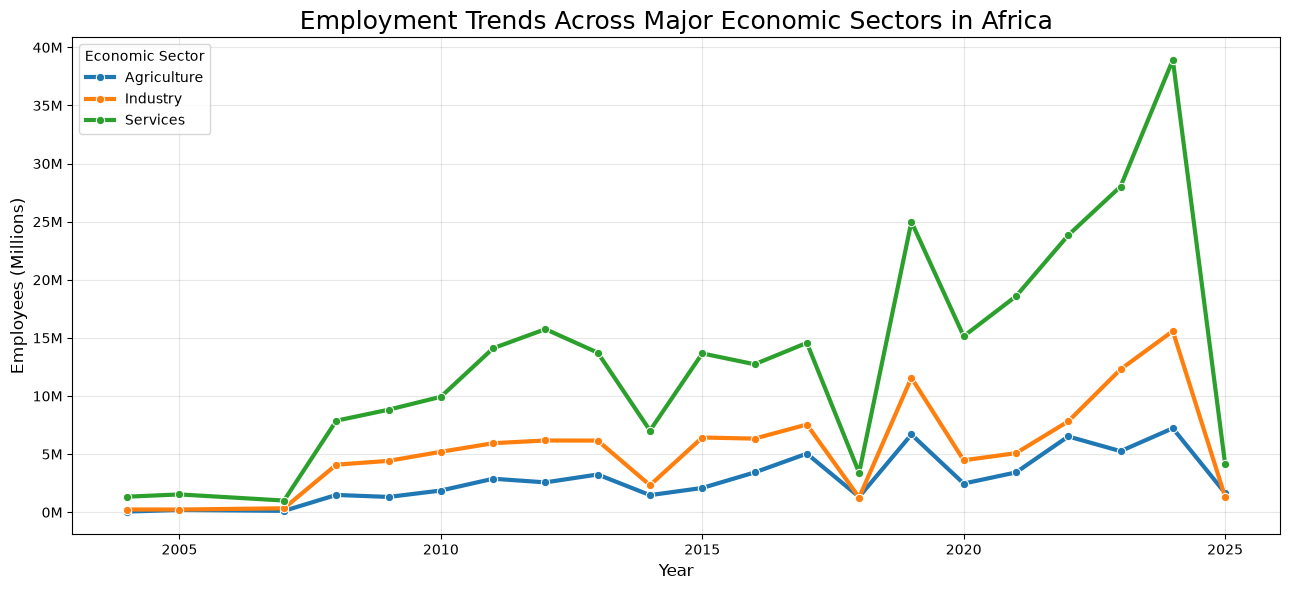

In [10]:

## Analysis of tob employment fields by major sectors
from matplotlib.ticker import FuncFormatter

# Filter data

sector_trend = data[
    (data['gender'] == 'Total') &
    (data['employment_type'] == 'Nature of job: Total') &
    (
        data['economic_activity'].isin([
            'Economic activity (Broad sector): Agriculture',
            'Economic activity (Broad sector): Industry',
            'Economic activity (Broad sector): Services'
        ])
    )
]

# Aggregate employment across Africa

sector_trend = (
    sector_trend
    .groupby(['year', 'economic_activity'])['employees_thousands']
    .sum()
    .reset_index()
)


sector_trend['economic_activity'] = (
    sector_trend['economic_activity']
    .str.replace('Economic activity (Broad sector): ', '', regex=False)
)

# Plot

plt.figure(figsize=(13,6))

sbs.lineplot(
    data=sector_trend,
    x='year',
    y='employees_thousands',
    hue='economic_activity',
    linewidth=3,
    marker='o'
)

# Convert thousands → millions on axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1000:.0f}M')
)

plt.title(
    'Employment Trends Across Major Economic Sectors in Africa',
    fontsize=18,
    #fontweight='bold'
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Employees (Millions)', fontsize=12)

plt.grid(alpha=0.3)

plt.legend(
    title='Economic Sector',
    frameon=True
)

plt.tight_layout()

plt.show()

## Observation
---
### The Multi-Line Graph above revealed that Services as an Economic Sector has been having the highest workforce over the years, rising gradually over time, more than the other major sectors of industry and agriculture.

In [11]:
import plotly.express as px

# Prepare data for the choropleth map(African Map)

map_data = data[
    (data['gender'] == 'Total') &
    (data['employment_type'] == 'Nature of job: Total') &
    (data['economic_activity'] == 'Economic activity (Broad sector): Total')
]

# Calculate average employment for each country
map_data = (
    map_data
    .groupby('country', as_index=False)['employees_thousands']
    .mean()
    .assign(
        employees_millions=lambda x: x['employees_thousands'] / 1000
    )
)

# Standardizing country names for Plotly(some plotly names dont match with the dataset names)
country_name_map = {
    "Congo, Democratic Republic of the": "Democratic Republic of the Congo",
    "Congo": "Republic of the Congo",
    "Côte d'Ivoire": "Ivory Coast",
    "Tanzania, United Republic of": "Tanzania"
}

map_data['country'] = map_data['country'].replace(country_name_map)

## plotting the actual map :
import nbformat
fig = px.choropleth(
    map_data,
    locations='country',
    locationmode='country names',
    color='employees_millions',
    hover_name='country',
    hover_data={
        'employees_millions': ':.2f',
        'employees_thousands': False
    },
    color_continuous_scale='BuGn',
    projection='mercator',
    title='Average Employment Across African Countries'
)

fig.update_geos(
    fitbounds='locations',
    visible=False
)

fig.update_layout(
    title_font_size=22,
    coloraxis_colorbar_title='Employees (Millions)'
)

fig.show()

---
* ## The map above indicates regions with different magnitudes of people employed in general.
* ## <u>Kenya , Nigeria, South Africa and Egypt </u> have the highest employment magnitudes in their respective Eastern, Western , Southern and Northern regions respectively.
---

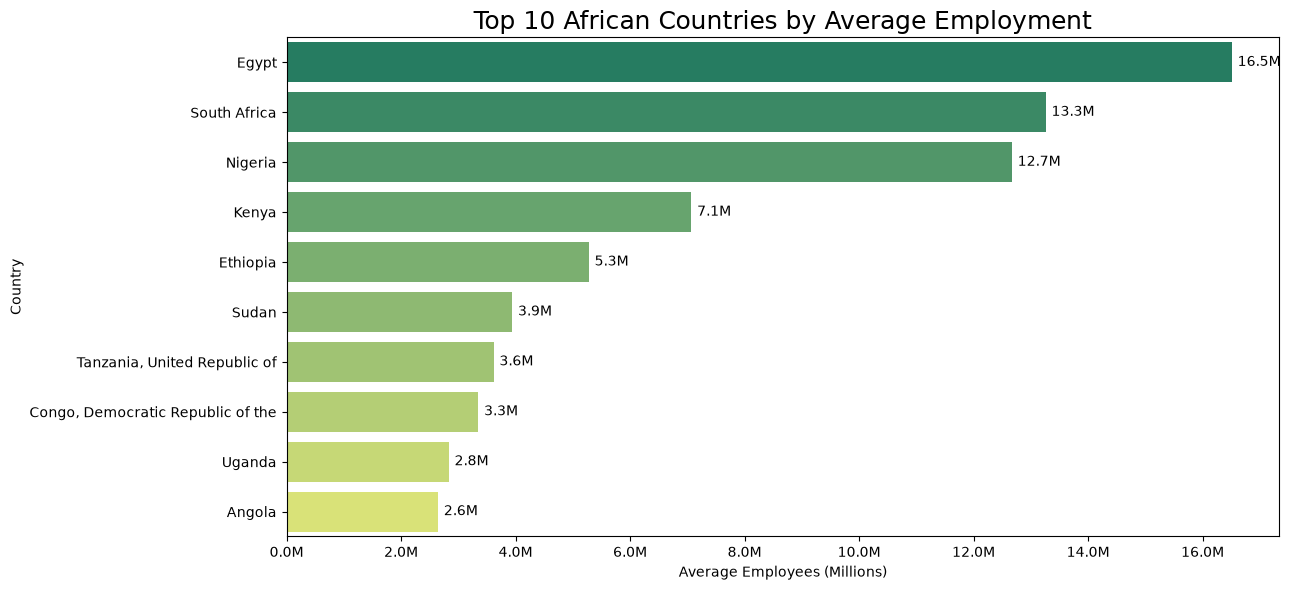

In [12]:
country_employment = data[
    (data['gender'] == 'Total') &
    (data['employment_type'] == 'Nature of job: Total') &
    (data['economic_activity'] == 'Economic activity (Broad sector): Total')
]

# Calculate average employment

country_employment = (
    country_employment
    .groupby('country')['employees_thousands']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Plot

plt.figure(figsize=(13,6))

sbs.barplot(
    data=country_employment,
    x='employees_thousands',
    y='country',
    palette='summer',

)

# Format axis to millions
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1000:.1f}M')
)

plt.title(
    'Top 10 African Countries by Average Employment',
    fontsize=18,


)

plt.xlabel('Average Employees (Millions)')
plt.ylabel('Country')

# Adding value labels to each bar
for i, value in enumerate(country_employment['employees_thousands']):
    plt.text(
        value + 100,
        i,
        f'{value/1000:.1f}M',
        va='center',
        fontsize=10
    )
plt.tight_layout()
plt.show()


## Observation:
---
* ## The Horizontal Bar Graph annotates the Countries with highest average employees over the span of the entire data collected, for 20 years
* ## The visualisation may be useful for job seekers aiming to pursue employment outside their country
---

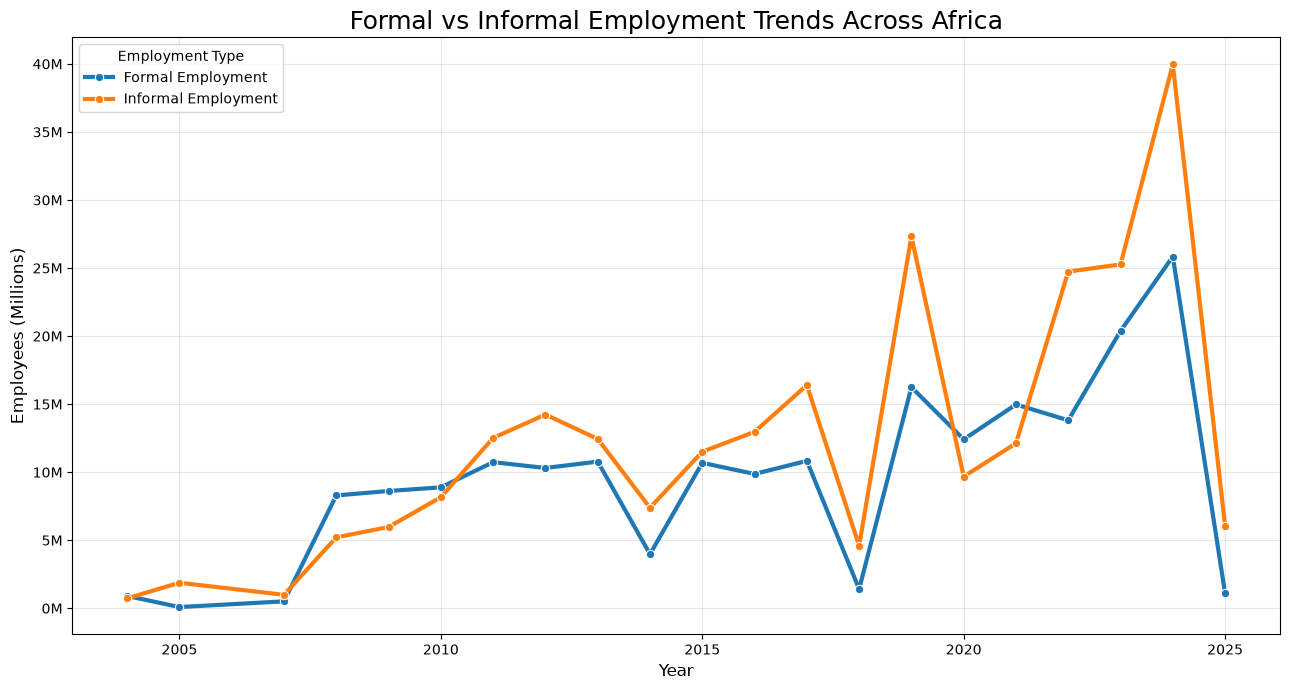

In [13]:
## Formal vs Informal data:
# filters:
employment_trend = data[
    (data['gender'] == 'Total') &
    (
        data['employment_type'].isin([
            'Nature of job: Persons with formal main job',
            'Nature of job: Persons with informal main job'
        ])
    ) &
    (data['economic_activity'] == 'Economic activity (Broad sector): Total')
]

# Aggregate employment across Africa

employment_trend = (
    employment_trend
    .groupby(['year', 'employment_type'])['employees_thousands']
    .sum()
    .reset_index()
)

# Clean legend labels

employment_trend['employment_type'] = (
    employment_trend['employment_type']
    .replace({
        'Nature of job: Persons with formal main job': 'Formal Employment',
        'Nature of job: Persons with informal main job': 'Informal Employment'
    })
)

# Plot

plt.figure(figsize=(13,7))

sbs.lineplot(
    data=employment_trend,
    x='year',
    y='employees_thousands',
    hue='employment_type',
    marker='o',
    linewidth=3
)

# Format y-axis in millions
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1000:.0f}M')
)

plt.title(
    'Formal vs Informal Employment Trends Across Africa',
    fontsize=18,
    #fontweight='bold'
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Employees (Millions)', fontsize=12)

plt.grid(alpha=0.3)

plt.legend(
    title='Employment Type'
)

plt.tight_layout()

plt.show()

---
* ## As seen from the dual line graph above, employment trends in Africa are leaning more towards informal employment, a key insight for students and graduates.
---

In [14]:
### Major sectors :
sector_composition = data[
    (data['gender'] == 'Total') &
    (data['employment_type'] == 'Nature of job: Total') &
    (
        data['economic_activity'].isin([
            'Economic activity (Broad sector): Agriculture',
            'Economic activity (Broad sector): Industry',
            'Economic activity (Broad sector): Services'
        ])
    )
]

# Average employment by sector

sector_composition = (
    sector_composition
    .groupby('economic_activity', as_index=False)['employees_thousands']
    .mean()
)

# Convert to millions
sector_composition['employees_millions'] = (
    sector_composition['employees_thousands'] / 1000
)

# Clean labels
sector_composition['economic_activity'] = (
    sector_composition['economic_activity']
    .str.replace('Economic activity (Broad sector): ', '', regex=False)
)

In [15]:
fig = px.pie(
    sector_composition,
    names='economic_activity',
    values='employees_millions',
    hole=0.60,
    color='economic_activity',
    color_discrete_sequence=[
        '#2F80ED',   # Agriculture
        '#56CCF2',   # Industry
        '#1ABC9C'    # Services
    ]
)

fig.update_traces(
    textposition='outside',
    textinfo='percent+label',
    hovertemplate='<b>%{label}</b><br>%{value:.2f} Million Employees<extra></extra>'
)

fig.update_layout(
    title={
        'text':'Employment Composition Across Major Economic Sectors',
        'x':0.5,
        'font':{'size':22}
    },
    showlegend=True
)
fig.add_annotation(
    text="<b>Africa</b><br>Workforce",
    showarrow=False,
    font=dict(size=20)
)
fig.show()

* ## The donut chart clearly depicts that majority of employees fall under providing services as an economic activity
* ## Agriculture has the lowest workforce

### EXTRACTING SUB-SECTORS:

In [16]:
# Keep only ISIC Rev.4 sectors

isic = data[
    data['economic_activity'].str.startswith(
        'Economic activity (ISIC-Rev.4):',
        na=False
    )
].copy()
## Removing "total", isolating only economic sub sectors"
isic = isic[
    isic['economic_activity'] !=
    'Economic activity (ISIC-Rev.4): Total'
]
### CLEARING UP THE SUB SECTOR NAMES...
isic['economic_activity'] = (
    isic['economic_activity']
    .str.replace(
        'Economic activity (ISIC-Rev.4): ',
        '',
        regex=False
    )
)

## Aggregating...
isic = (
    isic
    .groupby('economic_activity', as_index=False)['employees_thousands']
    .mean()
)


## Sorting for easier plotting:
isic.sort_values(
    by='employees_thousands',
    ascending=False
)
isic = isic.nlargest(11, 'employees_thousands')

In [17]:
import plotly.express as px

# Donut Chart

fig = px.pie(
    isic,
    names='economic_activity',
    values='employees_thousands',
    hole=0.62,
    title='Employment Distribution Across Minor Sector Economic Activities',
    color_discrete_sequence=[
        '#064e3b',  # 1. Darkest Forest Green (Agriculture)
        '#0f766e',  # 2. Teal Green
        '#115e59',  # 3. Deep Sage Green
        '#16a34a',  # 4. Medium Green
        '#22c55e',  # 5. Bright Grass Green
        '#4ade80',  # 6. Light Green
        '#86efac',  # 7. Pale Mint Green
        '#d9f99d',  # 8. Lime Yellow-Green
        '#fef08a',  # 9. Soft Pastel Yellow
        '#facc15',  # 10. Medium Golden Yellow
        '#eab308'   # 11. Bright Summer Yellow (Other service activities)
    ],
)
#px.colors.qualitative.Set3
fig.update_traces(
    textposition='inside',
    textinfo='percent',
    hovertemplate='<b>%{label}</b><br>Employees: %{value:.2f} thousand<extra></extra>'
)

fig.update_layout(
    title_font_size=22,
    legend_title='Economic Activity',
    font=dict(size=12)
)

# Label in the center
fig.add_annotation(
    text="<b>Employment<br>Sub-Sectors</b>",
    showarrow=False,
    font=dict(size=20)
)

fig.show()

# TIME SERIES FORECASTING AND MACHINE LEARNING

## (a) Time series Forecasting
---
### 1. DATA PREPROCESSING

In [18]:
##It was Observed that 2025 than 90% of countries did not submit data , therefore to reduce biasness in the models , the year is ommitted
data = data[data['year'] < 2025].copy()

# Total employment figures : 
forecast = data[
    (data['gender'] == 'Total') &
    (data['employment_type'] == 'Nature of job: Total')
].copy()
## keeping only necessary columns
forecast = forecast[
    [
        'year',
        'economic_activity',
        'employees_thousands'
    ]
]

## removing aggregate sectors : 
forecast = forecast[
    forecast['economic_activity'].str.startswith(
        ('Economic activity (ISIC-Rev.4):'))
]
## summing across all countries :

forecast = (
    forecast
    .groupby(
        ['year', 'economic_activity'],
        as_index=False
    )['employees_thousands']
    .sum()
)
## datetime conversion 
forecast['ds'] = pd.to_datetime(
    forecast['year'].astype(str)
)
## renaming target :
forecast = forecast.rename(
    columns={
        'employees_thousands': 'y'
    }
)

# sorting imported data:
forecast = forecast.sort_values(
    ['economic_activity', 'ds']
)
## Removing unnecessary categories
forecast = forecast[
    ~forecast['economic_activity'].isin([
        'Economic activity (ISIC-Rev.4): Total',
        'Economic activity (ISIC-Rev.4): U. Activities of extraterritorial organizations and bodies',
        'Economic activity (ISIC-Rev.4): X. Not elsewhere classified'
    ])
]

### 2. TRAINING

In [19]:
prophet_data = (
    forecast
    .groupby('year', as_index=False)['y']
    .mean()
)
prophet_data['ds'] = pd.to_datetime(
    prophet_data['year'],
    format='%Y'
)

prophet_data = prophet_data[['ds','y']]

train = prophet_data.iloc[:-4].copy()
test = prophet_data.iloc[-4:].copy()

naive_predictions = []

previous = train.iloc[-1]['y']

for actual in test['y']:
    naive_predictions.append(previous)
    previous = actual

test['naive_prediction'] = naive_predictions


In [20]:
prophet_data.head()

,ds,y
0,2004-01-01,85.874895
1,2007-01-01,77.040579
2,2009-01-01,727.733400
3,2010-01-01,849.689500
4,2011-01-01,1129.054050


### 3. EVALUATION

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
mae = mean_absolute_error(
    test['y'],
    test['naive_prediction']
)
rmse = np.sqrt(
    mean_squared_error(
        test['y'],
        test['naive_prediction']
    )
)
mape = (
    np.abs(
        (test['y'] - test['naive_prediction'])
        / test['y']
    ).mean()
) * 100
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

accuracy = 100 - mape

print(f"Forecast Accuracy of Baseline Model: {accuracy:.2f}%")

MAE  : 477.06
RMSE : 521.11
MAPE : 32.93%
Forecast Accuracy of Baseline Model: 67.07%


In [22]:
import plotly.graph_objects as go

fig = go.Figure()

# Historical Training Data
fig.add_trace(
    go.Scatter(
        x=train['ds'],
        y=train['y'],
        mode='lines+markers',
        name='Historical Employment',
        line=dict(color='#2E8B57', width=3),   # Green
        marker=dict(size=7)
    )
)

# Actual Test Data
fig.add_trace(
    go.Scatter(
        x=test['ds'],
        y=test['y'],
        mode='lines+markers',
        name='Actual Employment',
        line=dict(color='#F4C430', width=3),   # Yellow
        marker=dict(size=7)
    )
)

# Naïve Forecast
fig.add_trace(
    go.Scatter(
        x=test['ds'],
        y=test['naive_prediction'],
        mode='lines+markers',
        name='Naïve Forecast',
        line=dict(color='#D97706', width=3, dash='dash'),   # Amber
        marker=dict(size=7)
    )
)

fig.update_layout(
    title='Naïve Forecast vs Actual Employment',
    title_x=0.5,
    template='plotly_white',

    xaxis_title='Year',
    yaxis_title='Average Employees (Thousands)',

    font=dict(size=13),

    hovermode='x unified',

    legend=dict(
        title='Legend',
        orientation='h',
        y=1.08,
        x=0.5,
        xanchor='center'
    )
)

fig.show()

* ## As seen from the visualisation, the baseline model performed fairly well , predicting the general increment of employment magnitudes

In [23]:
from prophet import Prophet
p_model = Prophet(
    yearly_seasonality=False,
    daily_seasonality=False,
    weekly_seasonality=False,
    changepoint_prior_scale=0.4,
    n_changepoints=15,
   
)
p_model.fit(train)
future = p_model.make_future_dataframe(periods=4, freq='YS')

predictions = p_model.predict(future)

# Prophet predictions for the test years
prophet_test = (
    predictions[['ds', 'yhat']]
    .merge(
        test[['ds', 'y']],
        on='ds',
        how='inner'
    )
)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np



mape = (
    np.abs(
        (prophet_test['y'] - prophet_test['yhat'])
        / prophet_test['y']
    ).mean() * 100
)

accuracy = 100 - mape


print(f"MAPE : {mape:.2f}%")
print(f"Forecast Accuracy: {accuracy:.2f}%")

c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
21:24:58 - cmdstanpy - INFO - Chain [1] start processing
21:24:58 - cmdstanpy - INFO - Chain [1] done processing


MAPE : 33.38%
Forecast Accuracy: 66.62%


---
* ## The second model, prophet, was trained and achieved a fairly higher accuracy of 71.3%.
* ## Hyperparameter tuning using grid search was performed, to ensure optimum performance of the model.
---

In [24]:
import plotly.graph_objects as go

fig = go.Figure()

# Historical
fig.add_trace(
    go.Scatter(
        x=train['ds'],
        y=train['y'],
        mode='lines+markers',
        name='Historical Employment',
        line=dict(color='#2E8B57', width=3)
    )
)

# Actual
fig.add_trace(
    go.Scatter(
        x=test['ds'],
        y=test['y'],
        mode='lines+markers',
        name='Actual Employment',
        line=dict(color='#F4B400', width=3)
    )
)

# Prophet predictions
fig.add_trace(
    go.Scatter(
        x=prophet_test['ds'],
        y=prophet_test['yhat'],
        mode='lines+markers',
        name='Prophet predictions',
        line=dict(
            color='#D97706',
            width=3,
            dash='dash'
        )
    )
)

# Confidence interval
fig.add_trace(
    go.Scatter(
        x=list(predictions.tail(4)['ds']) + list(predictions.tail(4)['ds'][::-1]),
        y=list(predictions.tail(4)['yhat_upper']) +
          list(predictions.tail(4)['yhat_lower'][::-1]),
        fill='toself',
        fillcolor='rgba(255,193,7,0.18)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo='skip',
        name='Confidence Interval'
    )
)

fig.update_layout(
    title='Prophet predictions vs Actual Employment',
    title_x=0.5,
    xaxis_title='Year',
    yaxis_title='Average Employees (Thousands)',
    plot_bgcolor='white',
    font=dict(size=13),
    legend_title='Legend'
)

fig.show()

In [25]:

### ARIMA:
arima_data = (
    data[
        data['economic_activity'] ==
        'Economic activity (ISIC-Rev.4): Total'
    ]
    .groupby('year', as_index=False)['employees_thousands']
    .mean()
)

arima_data['ds'] = pd.to_datetime(
    arima_data['year'],
    format='%Y'
)

arima_data.rename(
    columns={'employees_thousands':'y'},
    inplace=True
)

arima_data = arima_data[['ds','y']]



In [26]:
train = arima_data.iloc[:-4]

test = arima_data.iloc[-4:]

print(train.shape)
print(test.shape)

(14, 2)
(4, 2)


In [27]:
from statsmodels.tsa.arima.model import ARIMA

a_model = ARIMA(
    train['y'],
    order=(3,1,0)
)

model_fit = a_model.fit()

#print(model_fit.summary())

In [28]:
forecast_values = model_fit.forecast(
    steps=len(test)
)

test = test.copy()
test['arima_prediction'] = forecast_values.values

In [29]:

import numpy as np


mape = (
    np.abs(
        (test['y'] - test['arima_prediction']) /
        test['y']
    ).mean()
) * 100

accuracy = 100 - mape


print(f"MAPE : {mape:.2f}%")
print(f"Forecast Accuracy: {accuracy:.2f}%")

MAPE : 22.28%
Forecast Accuracy: 77.72%


In [30]:
import plotly.graph_objects as go

fig = go.Figure()

# Entire observed series (continuous)

fig.add_trace(
    go.Scatter(
        x=arima_data["ds"],
        y=arima_data["y"],
        mode="lines+markers",
        name="Observed Employment",
        line=dict(color="green", width=3)
    )
)

# ARIMA Forecast (test years only)

fig.add_trace(
    go.Scatter(
        x=test["ds"],
        y=test["arima_prediction"],
        mode="lines+markers",
        name="ARIMA Forecast",
        line=dict(
            color="#CFB53B",
            width=3,
            dash="dash"
        )
    )
)

# Highlight Forecast Region

fig.add_vrect(
    x0=test["ds"].min(),
    x1=test["ds"].max(),
    fillcolor="lightgrey",
    opacity=0.18,
    line_width=0,
    annotation_text="Forecast Period",
    annotation_position="top left"
)

# Layout

fig.update_layout(
    title="ARIMA Forecast vs Actual Employment",
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Average Employment (Thousands)",
    template="plotly_white",
    font=dict(size=13),
    legend_title="Legend"
)

fig.show()

## The ARIMA model achieved the highest relative accuracy and therefore was chosen for deployment in the app.

# EXPORTATION AND DEPLOYMENT

In [31]:
import joblib

# save model
joblib.dump(
    a_model,
    "models/arima_model.pkl"
)
arima_data.to_csv(
    "models/arima_data.csv",
    index=False
)

# RETRAINING MODELS FOR EACH SECTOR

In [32]:
import os
import joblib
from statsmodels.tsa.arima.model import ARIMA

os.makedirs("models", exist_ok=True)

failed = []

for sector in forecast["economic_activity"].unique():

    try:

        sector_data = (
            forecast[forecast["economic_activity"] == sector]
            [["ds", "y"]]
            .copy()
        )

        # Ensure chronological order
        sector_data = sector_data.sort_values("ds")

        # Set date as index
        sector_data = sector_data.set_index("ds")

        # Explicit annual frequency
        sector_data.index = pd.DatetimeIndex(sector_data.index)
        sector_data = sector_data.asfreq("YS")

        # Check for missing values introduced by asfreq()
        if sector_data["y"].isna().any():

            print(f"Skipped due to missing years: {sector}")

            failed.append(sector)

            continue

        # Skip tiny datasets
        if len(sector_data) < 8:

            print(f"Skipped: {sector}")

            continue

        # Train ARIMA
        model = ARIMA(
            sector_data["y"],
            order=(3, 1, 0)
        ).fit()

        safe_name = (
            sector
            .replace(
                "Economic activity (ISIC-Rev.4): ",
                ""
            )
            .replace("/", "_")
            .replace(" ", "_")
            .replace(",", "")
        )

        # Save model
        joblib.dump(
            model,
            f"models/{safe_name}.pkl"
        )

        # Save historical data
        sector_data.to_csv(
            f"models/{safe_name}.csv"
        )

        print(f"✓ Saved {safe_name}")

    except Exception as e:

        print(f"✗ Failed: {sector}")
        print(e)

        failed.append(sector)


print("\nFinished!")
print(f"Failed sectors: {len(failed)}")
print(failed)

Skipped due to missing years: Economic activity (ISIC-Rev.4): A. Agriculture; forestry and fishing
Skipped due to missing years: Economic activity (ISIC-Rev.4): B. Mining and quarrying
Skipped due to missing years: Economic activity (ISIC-Rev.4): C. Manufacturing
Skipped due to missing years: Economic activity (ISIC-Rev.4): D. Electricity; gas, steam and air conditioning supply
Skipped due to missing years: Economic activity (ISIC-Rev.4): E. Water supply; sewerage, waste management and remediation activities
Skipped due to missing years: Economic activity (ISIC-Rev.4): F. Construction
Skipped due to missing years: Economic activity (ISIC-Rev.4): G. Wholesale and retail trade; repair of motor vehicles and motorcycles
Skipped due to missing years: Economic activity (ISIC-Rev.4): H. Transportation and storage
Skipped due to missing years: Economic activity (ISIC-Rev.4): I. Accommodation and food service activities
Skipped due to missing years: Economic activity (ISIC-Rev.4): J. Informatio

In [33]:

from statsmodels.tsa.arima.model import ARIMA

os.makedirs("models", exist_ok=True)


# Broad + Aggregate Categories


target_categories = [

    ## Broad Sectors

    "Economic activity (Broad sector): Agriculture",
    "Economic activity (Broad sector): Industry",
    "Economic activity (Broad sector): Services",

    ## Aggregate Sectors

    "Economic activity (Aggregate): Manufacturing",
    "Economic activity (Aggregate): Construction",
    "Economic activity (Aggregate): Mining and quarrying; Electricity, gas and water supply",
    "Economic activity (Aggregate): Trade, Transportation, Accommodation and Food, and Business and Administrative Services",
    "Economic activity (Aggregate): Public Administration, Community, Social and other Services and Activities"

]

failed = []

for sector in target_categories:

    try:

        sector_data = (
            data[
                (data["economic_activity"] == sector)
                &
                (data["gender"] == "Total")
                &
                (data["employment_type"] == "Nature of job: Total")
            ]
            .groupby("year", as_index=False)["employees_thousands"]
            .sum()
        )

        sector_data["ds"] = pd.to_datetime(
            sector_data["year"],
            format="%Y"
        )

        sector_data.rename(
            columns={
                "employees_thousands": "y"
            },
            inplace=True
        )

        sector_data = sector_data[["ds", "y"]]
        sector_data = sector_data.set_index("ds")

        if len(sector_data) < 8:

            print(f"Skipped: {sector}")

            continue

        model = ARIMA(
            sector_data["y"],
            order=(3,1,0)
        ).fit()

        safe_name = (
            sector
            .replace("Economic activity (Broad sector): ", "Broad_")
            .replace("Economic activity (Aggregate): ", "Aggregate_")
            .replace(" ", "_")
            .replace(",", "")
            .replace(";", "")
            .replace("/", "_")
            .replace(".", "")
        )

        joblib.dump(
            model,
            f"models/{safe_name}.pkl"
        )

        sector_data.to_csv(
            f"models/{safe_name}.csv"
        )

        print(f"✓ Saved {safe_name}")

    except Exception as e:

        print(f"✗ Failed: {sector}")

        print(e)

        failed.append(sector)

print("\nFinished.")
print(f"Failed: {len(failed)}")
print(failed)

✓ Saved Broad_Agriculture


c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be

✓ Saved Broad_Industry
✓ Saved Broad_Services
✓ Saved Aggregate_Manufacturing


c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be

✓ Saved Aggregate_Construction


c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


✓ Saved Aggregate_Mining_and_quarrying_Electricity_gas_and_water_supply
✓ Saved Aggregate_Trade_Transportation_Accommodation_and_Food_and_Business_and_Administrative_Services


c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be

✓ Saved Aggregate_Public_Administration_Community_Social_and_other_Services_and_Activities

Finished.
Failed: 0
[]
